# Punto 6 — Evaluación en entrenamiento y prueba

En este punto se revisa qué tan bien predicen los modelos elegidos en el punto 5. Se utilizan **2023–2024 para entrenar** y **2025 para probar**. Los datos conservan su orden por fecha.

## ¿Cómo se mide el error?

El error es la diferencia entre el valor real y la predicción. Se calculan tres medidas:

- **MAE (error absoluto promedio):** indica cuánto se equivoca el modelo en promedio, sin considerar si predice de más o de menos. Por ejemplo, un MAE de 4 °C significa que las predicciones se alejan, en promedio, 4 °C de la temperatura real.
- **RMSE (raíz del error cuadrático medio):** da más peso a los errores grandes. Si es mucho mayor que el MAE, algunos errores grandes tienen una influencia importante.
- **Sesgo (error promedio con signo):** indica la dirección del error. Un valor positivo significa que el modelo predice menos de lo observado; uno negativo, que predice más.

Para MAE y RMSE, **un valor menor indica mayor precisión**. Las medidas se expresan en la unidad de cada serie: viajes, °C, puntos porcentuales de humedad o mm de lluvia. No se comparan directamente errores de variables con unidades distintas.

No se utiliza MAPE, una medida de error porcentual, porque requiere dividir por el valor real y la precipitación contiene ceros.

## ¿Cómo se hace la evaluación?

**En entrenamiento**, se predice cada día con los valores reales de los días anteriores. Los parámetros se calcularon con todo el período de entrenamiento, por lo que estos errores describen el ajuste a datos ya utilizados. Se dejan fuera las primeras 30 predicciones, o más si el modelo necesita un inicio más largo. Si se aplicó la diferencia anual, tampoco se evalúan los primeros 365 días, porque se usaron como referencia.

**En prueba**, el modelo parte del 31/12/2024 y predice todo 2025. No recibe los valores reales de 2025 ni se actualiza durante ese año. Se calcula el error de los 365 días y, por separado, el de los primeros 30 días. Este segundo resultado permite observar cómo le fue al comienzo; no se usa para cambiar el modelo elegido.

Las dos evaluaciones tienen distinta dificultad. En entrenamiento se conocen los valores reales anteriores a cada día. En prueba se predicen muchos días seguidos sin esa información nueva. Por eso, un error mayor en prueba no demuestra por sí solo que el modelo haya aprendido demasiado los datos de entrenamiento.

Además, el modelo se eligió por su error en una validación de 90 días. El que funciona mejor para ese plazo puede no ser el más adecuado para predecir un año completo.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/bicicletas_rosario.csv').exists())
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))
from modelos_puntos56 import cargar, seleccionar, ajustar, ajustados, pronosticar, metricas, etiqueta
series = cargar(ROOT)
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110})


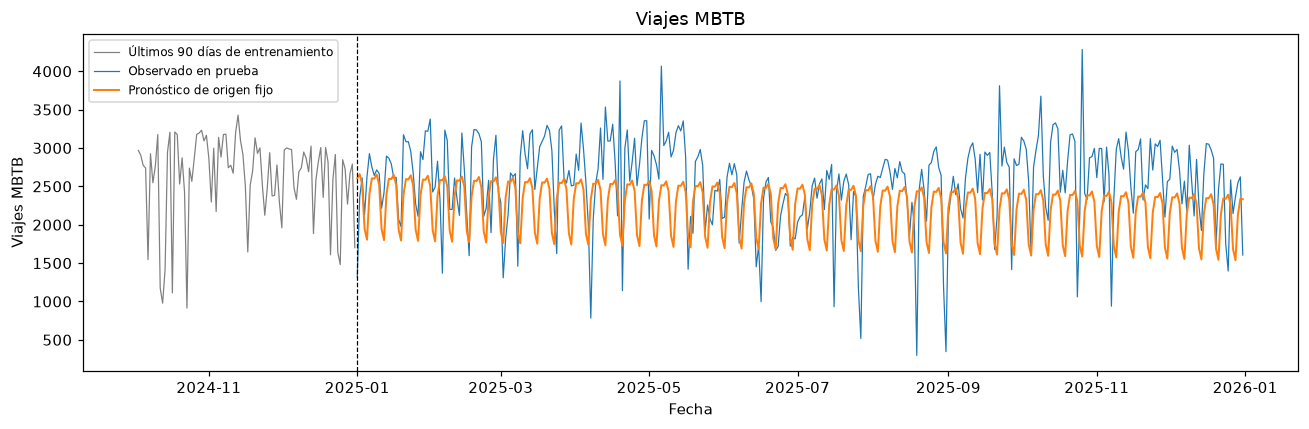

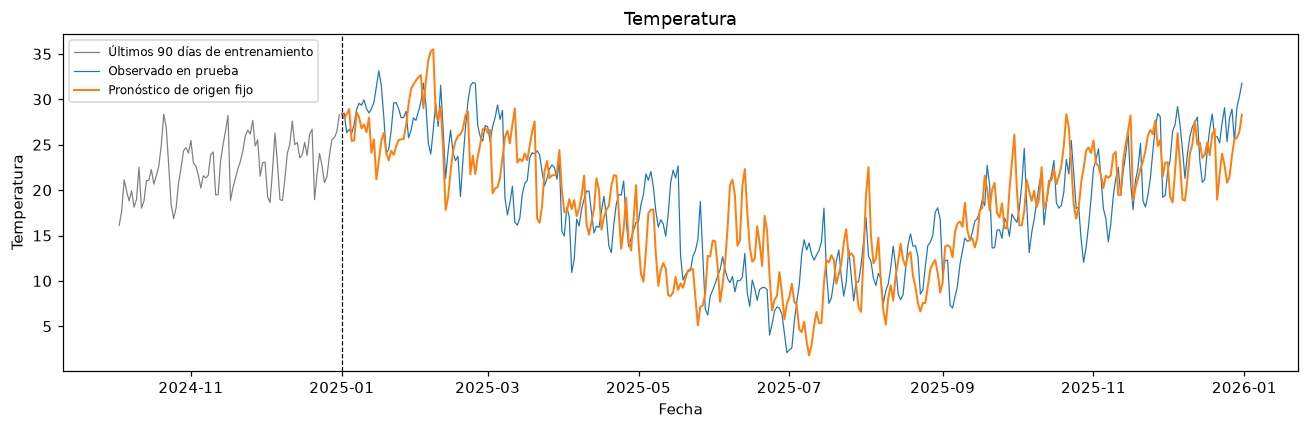

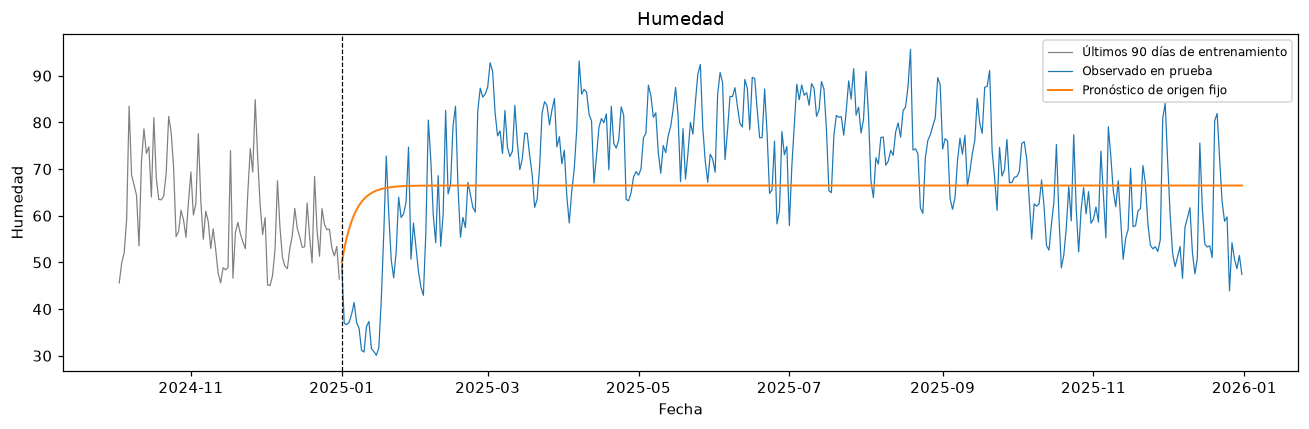

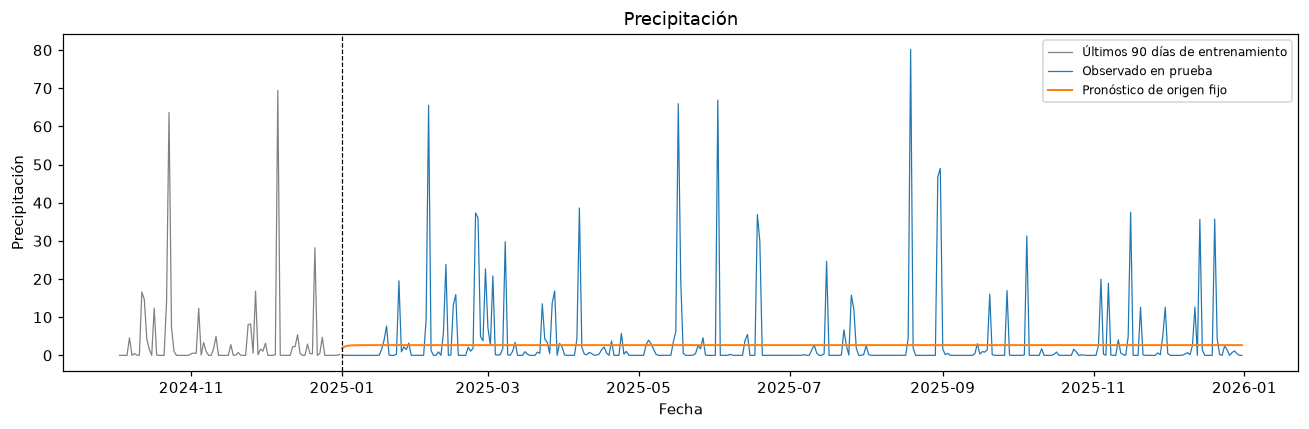

,serie,modelo,conjunto,inicio,fin,n,MAE,RMSE,sesgo
0,Viajes MBTB,"SARIMA(0, 1, 1)×(0, 1, 1, 7)",Training (1 paso),2023-01-31,2024-12-31,701,364.764,520.784,-8.569
1,Viajes MBTB,"SARIMA(0, 1, 1)×(0, 1, 1, 7)",Testing (365 días),2025-01-01,2025-12-31,365,512.524,635.599,334.702
2,Viajes MBTB,"SARIMA(0, 1, 1)×(0, 1, 1, 7)",Testing (30 días),2025-01-01,2025-01-30,30,361.645,456.114,252.870
3,Temperatura,"SARIMA(1, 0, 0)×(0, 1, 0, 365)",Training (1 paso),2024-01-31,2024-12-31,336,2.659,3.410,-0.180
4,Temperatura,"SARIMA(1, 0, 0)×(0, 1, 0, 365)",Testing (365 días),2025-01-01,2025-12-31,365,3.959,4.926,-0.065
5,Temperatura,"SARIMA(1, 0, 0)×(0, 1, 0, 365)",Testing (30 días),2025-01-01,2025-01-30,30,3.013,3.896,1.929
6,Humedad,"SARIMA(1, 0, 0)×(0, 0, 0, 0)",Training (1 paso),2023-01-31,2024-12-31,701,6.097,7.968,0.191
7,Humedad,"SARIMA(1, 0, 0)×(0, 0, 0, 0)",Testing (365 días),2025-01-01,2025-12-31,365,11.474,13.611,3.451
8,Humedad,"SARIMA(1, 0, 0)×(0, 0, 0, 0)",Testing (30 días),2025-01-01,2025-01-30,30,18.185,21.072,-17.175
9,Precipitación,"SARIMA(1, 0, 1)×(0, 0, 0, 0)",Training (1 paso),2023-01-31,2024-12-31,701,3.874,8.155,-0.012


In [2]:
archivo = ROOT / 'puntos/punto5/seleccion.json'
if not archivo.exists():
    raise FileNotFoundError('Ejecutar primero punto5.ipynb para guardar los modelos seleccionados.')
seleccionados = json.loads(archivo.read_text())
OUT = ROOT / 'puntos/punto6'
OUT.mkdir(exist_ok=True)
filas, predicciones = [], []
for nombre, s in series.items():
    train, test = s.loc[:'2024-12-31'], s.loc['2025-01-01':]
    assert train.index.max() < test.index.min() and len(test) == 365
    c = seleccionados[nombre]
    r, avisos = ajustar(train, c)
    pred_train = ajustados(r, train, c).iloc[max(30, int(r.loglikelihood_burn)):]
    pred_test = pronosticar(r, train, c, test.index)
    for conjunto, real, pred in [('Training (1 paso)', train.reindex(pred_train.index), pred_train),
                                  ('Testing (365 días)', test, pred_test),
                                  ('Testing (30 días)', test.iloc[:30], pred_test.iloc[:30])]:
        filas.append(dict(serie=nombre, modelo=etiqueta(c), conjunto=conjunto,
                          inicio=str(real.index.min().date()), fin=str(real.index.max().date()),
                          **metricas(real, pred)))
    for conjunto, real, pred in [('Training',train.reindex(pred_train.index),pred_train), ('Testing',test,pred_test)]:
        predicciones.append(pd.DataFrame({'fecha': real.index, 'serie': nombre, 'conjunto': conjunto,
                                         'observado': real.values, 'prediccion': pred.values,
                                         'error': (real-pred).values}))
    fig, ax = plt.subplots()
    ax.plot(train.iloc[-90:], color='gray', lw=.8, label='Últimos 90 días de entrenamiento')
    ax.plot(test, lw=.8, label='Observado en prueba')
    ax.plot(pred_test, lw=1.3, label='Pronóstico de origen fijo')
    ax.axvline(test.index[0], color='black', linestyle='--', lw=.8)
    ax.set(title=nombre, xlabel='Fecha', ylabel=nombre)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
resultados = pd.DataFrame(filas)
predicciones = pd.concat(predicciones, ignore_index=True)
resultados.to_csv(OUT / 'metricas_training_testing.csv', index=False)
predicciones.to_csv(OUT / 'predicciones_evaluacion.csv', index=False)
display(resultados.round(3))


## Resultados por serie

In [3]:
unidades = {'Viajes MBTB':'viajes', 'Temperatura':'°C', 'Humedad':'puntos porcentuales', 'Precipitación':'mm'}
for nombre in series:
    tabla = resultados[resultados.serie.eq(nombre)].set_index('conjunto')
    tr, te, corto = (tabla.loc[k] for k in ['Training (1 paso)', 'Testing (365 días)', 'Testing (30 días)'])
    direccion = 'subestimación' if te.sesgo > 0 else 'sobreestimación'
    display(Markdown(f'**{nombre}.** El MAE de entrenamiento es **{tr.MAE:.2f}** y el de prueba anual '
                     f'**{te.MAE:.2f} {unidades[nombre]}**. El RMSE anual es **{te.RMSE:.2f}**; '
                     f'el sesgo de **{te.sesgo:.2f}** indica {direccion} promedio. '
                     f'En los primeros 30 días, el MAE es **{corto.MAE:.2f}**. '
                     'Estas predicciones se hicieron sin incorporar los valores reales de 2025.'))
    prueba = predicciones[(predicciones.serie == nombre) & (predicciones.conjunto == 'Testing')]
    if nombre in ('Viajes MBTB','Precipitación'):
        display(Markdown(f'Se registran **{int((prueba.prediccion < 0).sum())}** pronósticos negativos, '
                         'que no tienen sentido para esta variable.'))


**Viajes MBTB.** El MAE de entrenamiento es **364.76** y el de prueba anual **512.52 viajes**. El RMSE anual es **635.60**; el sesgo de **334.70** indica subestimación promedio. En los primeros 30 días, el MAE es **361.65**. Estas predicciones se hicieron sin incorporar los valores reales de 2025.

Se registran **0** pronósticos negativos, que no tienen sentido para esta variable.

**Temperatura.** El MAE de entrenamiento es **2.66** y el de prueba anual **3.96 °C**. El RMSE anual es **4.93**; el sesgo de **-0.07** indica sobreestimación promedio. En los primeros 30 días, el MAE es **3.01**. Estas predicciones se hicieron sin incorporar los valores reales de 2025.

**Humedad.** El MAE de entrenamiento es **6.10** y el de prueba anual **11.47 puntos porcentuales**. El RMSE anual es **13.61**; el sesgo de **3.45** indica subestimación promedio. En los primeros 30 días, el MAE es **18.18**. Estas predicciones se hicieron sin incorporar los valores reales de 2025.

**Precipitación.** El MAE de entrenamiento es **3.87** y el de prueba anual **4.77 mm**. El RMSE anual es **10.35**; el sesgo de **0.87** indica subestimación promedio. En los primeros 30 días, el MAE es **2.84**. Estas predicciones se hicieron sin incorporar los valores reales de 2025.

Se registran **0** pronósticos negativos, que no tienen sentido para esta variable.

## Conclusión

Los modelos se eligieron con los datos de entrenamiento. Después se compararon sus predicciones con los valores reales de 2025. Las tablas muestran cuánto se equivocó cada modelo y si tendió a predecir de más o de menos.

Los resultados muestran que:

- **Viajes:** el modelo predijo, en promedio, menos viajes de los que se observaron en 2025. El patrón semanal puede no alcanzar para explicar los cambios a lo largo del año.
- **Temperatura:** se eligió un modelo con diferencia anual. Hay solo dos años de entrenamiento, lo que limita la información disponible para representar ese ciclo.
- **Humedad:** el error promedio de los primeros 30 días fue mayor que el del año completo. Predecir un período más corto no asegura un error menor: también influye qué días se evalúan.
- **Precipitación:** el RMSE anual fue bastante mayor que el MAE. Esto indica que algunos errores grandes tuvieron un peso importante en el resultado.

Estos modelos son una primera elección. En el punto 7 se compararán con otras alternativas y en el punto 8 se revisará si sus errores todavía presentan patrones. Los resultados corresponden a los archivos CSV del proyecto; aquí no se comprueba su procedencia externa.

**Herramientas:** Pandas y NumPy para las tablas y los errores; Matplotlib para los gráficos; statsmodels para los modelos. Las funciones compartidas están en `scripts/modelos_puntos56.py`.